In [2]:
import pandas as pd
from rapidfuzz.distance import Levenshtein
from tqdm.notebook import tqdm
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import chess
from IPython.display import display, HTML

In [7]:
total = 0
for param in model.parameters():
    total += param.numel()
total

268892160

In [53]:
base_path = Path("./Generate_positions/Lichess")
for path in os.listdir(base_path):
    if path[-4:] != ".csv":
        continue
    df = pd.read_csv(base_path / path)
    print(
        path[:-4],
        100 * df["is_legal"].mean(), 
        100 * df["is_puzzle"].mean(), 
        100 * df[df["is_puzzle"]]["counter_intuitive"].mean(), 
        100 * (df["is_puzzle"] & df["counter_intuitive"]).mean()
    )


lichess_first_time_move_found_division_50 100.0 83.57900000000001 1.5470393280608765 1.2930000000000001
lichess_first_time_move_found_division_50_small 100.0 83.24000000000001 1.5617491590581452 1.3
lichess_first_time_settled_on_move_division_50_small 100.0 83.26 3.687244775402354 3.0700000000000003


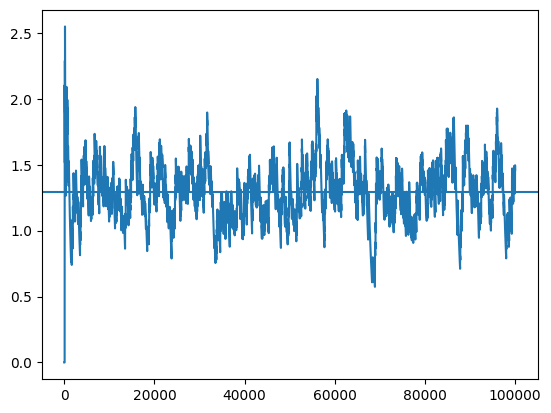

In [79]:
df = pd.read_csv(base_path / "lichess_first_time_move_found_division_50.csv")
(100 * (df["is_puzzle"] & df["counter_intuitive"])).ewm(alpha=1e-3).mean().plot()
plt.axhline((100 * (df["is_puzzle"] & df["counter_intuitive"])).mean(), 0, 100_000)
plt.show()

In [49]:
base_path = Path("./Generate_positions/final_model/supervised/first_time_move_found_division_50/")
for path in os.listdir(base_path):
    if path[-4:] != ".csv":
        continue
    df = pd.read_csv(base_path / path)
    print(
        path[:-4],
        100 * df["is_legal"].mean(), 
        100 * df["is_puzzle"].mean(), 
        100 * df["counter_intuitive"].mean(),
        100 * df[df["is_puzzle"]]["counter_intuitive"].mean(), 
        100 * (df["is_puzzle"] & df["counter_intuitive"]).mean()
    )


test_context_move_last 98.330078125 34.892578125 7.667097030489621 0.5037783375314862 0.17578125
test_context_no_move_last 99.453125 42.373046875 6.304006284367636 0.4839824844434202 0.205078125
train_context_move_last 98.037109375 35.1953125 7.729853571072816 0.4994450610432853 0.17578125
train_context_no_move_last 99.443359375 42.01171875 6.255523912403024 0.6276150627615062 0.263671875


In [47]:
import pandas as pd
import numpy as np
import asyncio
import sys
import os
from concurrent.futures import ThreadPoolExecutor
from functools import partial
from chess.engine import SimpleEngine
import warnings
import random
from metrics.themes import counter_intuitive, get_unique_puzzle_from_fen


warnings.simplefilter(action='ignore', category=FutureWarning)

if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

def process_fen_chunk(fens_chunk, compute_unique):
    results = []
    with SimpleEngine.popen_uci(r"..\Stockfish\src\stockfish") as engine:
        engine.configure({"Threads": 1})
        for fen in fens_chunk:
            ci = counter_intuitive(fen, engine)
            if compute_unique:
                is_unique = get_unique_puzzle_from_fen(fen, engine) is not None
                results.append((ci, is_unique))
            else:
                results.append(ci)
                
    return results

df = pd.read_csv("dataset/experiment_with_counter_intuitiveness.csv")
# df = pd.read_csv("dataset/dataset.csv", nrows=10000)
# df["unique"] = True  # uniqueness of the positions is around 85% so need to multiply metrics by 0.85

compute_uniqueness = "unique" not in df.columns
WORKERS = os.cpu_count() - 2
fen_chunks = np.array_split(df["Puzzle_FEN"], WORKERS)
worker_func = partial(process_fen_chunk, compute_unique=compute_uniqueness)

with ThreadPoolExecutor(max_workers=WORKERS) as executor:
    chunked_results = list(executor.map(worker_func, fen_chunks))

flat_results = [item for sublist in chunked_results for item in sublist]

if compute_uniqueness:
    ci_scores, unique_puzzles = zip(*flat_results)
    df["counter_intuitive"] = ci_scores
    df["unique"] = unique_puzzles
else:
    df["counter_intuitive"] = flat_results

print("Counter intuitive rate:", 100 * df["counter_intuitive"].mean())
print("Uniqueness rate:", 100 * df["unique"].mean())
print("Counter intuitive given Unique rate:", 100 * df[df["unique"]]["counter_intuitive"].mean())
print("Puzzle rate:", 100 * (df["unique"] & df["counter_intuitive"]).mean())

Counter intuitive rate: 1.7999999999999998
Uniqueness rate: 84.39999999999999
Counter intuitive given Unique rate: 2.132701421800948
Puzzle rate: 1.7999999999999998


In [22]:
index = -1
# df = pd.read_csv("./Generate_positions/final_model/supervised/test_context_move_last.csv")
df = pd.read_csv(base_path / "test_context_no_move_last.csv")
temp = df[df["is_legal"] & df["is_puzzle"] & df["counter_intuitive"] & df["themes_match"]]

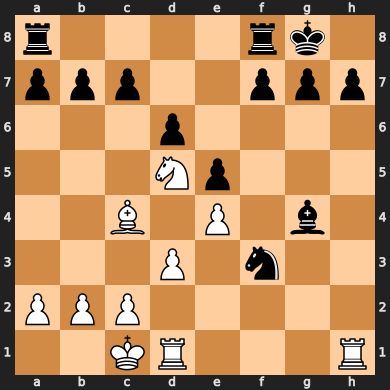

In [39]:
index = (index + 1) % len(temp)
row = temp.iloc[index]
board = chess.Board(row["fen"])
display(HTML(f"<h3>Puzzle {index + 1} / {len(temp)}</h3>"))
display(board)
display(HTML(f"<p style='font-size: 16px;'><b>Player to move:</b> {"white" if board.turn == chess.WHITE else "black"}</p>\n<p style='font-size: 16px;'><b>Solution:</b> {row['main_line']}</p>\n<p style='font-size: 16px;'><b>Themes:</b> {row['actual_themes']}</p><hr>"))


In [7]:
dataset = pd.read_csv("./dataset/dataset.csv", nrows=1000000)

In [15]:
from metrics.diversity_filtering import fen_to_padded


def closest_matches(fen, dataset, n = 3):
    board_fen = fen_to_padded(fen)
    distances = dataset["Puzzle_FEN"].apply(lambda x: Levenshtein.distance(fen_to_padded(x), board_fen))
    smallest = distances.nsmallest(n)
    closest_indices = smallest.index
    return dataset.loc[closest_indices][["Puzzle_FEN", "Themes", "Rating", "Moves"]], smallest.values

In [ ]:
def print_puzzles(puzzles):
    with pd.option_context("display.max_colwidth", 500):
        display(puzzles)

In [10]:
pos, dist = closest_matches("2r2rk1/pQ3ppp/4b3/6q1/8/8/PP3PPP/R1B1R1K1 b - - 0 20", dataset)
print_puzzles(pos["Puzzle_FEN"])

1506059       2r2rk1/pp3qpp/4R3/3Q4/8/8/PP3PPP/4R1K1 b - - 0 20
2336604     1r3rk1/pB3ppp/4b3/6q1/8/5Q2/PP3PPP/R4RK1 b - - 2 18
4794304    2r3k1/pp3ppp/4b3/3q2N1/8/8/PP3PPP/2Q1R1K1 w - - 1 23
Name: Puzzle_FEN, dtype: object

In [11]:
pos, dist = closest_matches("8/8/2pk4/4n1Q1/8/8/6K1/5r2 b - - 0 48", dataset)
print_puzzles(pos["Puzzle_FEN"])

922304      8/8/3pk3/4n1K1/8/8/3R4/8 b - - 4 58
2192897    8/8/2k5/4R1KP/8/8/6p1/6r1 w - - 0 51
4447866      8/8/8/5k1K/8/8/6R1/5r2 b - - 13 46
Name: Puzzle_FEN, dtype: object

In [ ]:
pos, dist = closest_matches("3r2k1/pp3p1p/6p1/4b3/4P2q/5Q2/PP4B1/R4RK1 b - - 0 26", dataset)
print_puzzles(pos["Puzzle_FEN"])

1289904       3rr1k1/pp3p1p/6p1/4b3/4N2q/5Q1P/PPPB1PP1/R4K2 w - - 6 23
477092     3r1rk1/pp3p1p/6p1/4bP2/1P2P2q/4Q2P/1P1B2P1/R4RK1 b - - 2 23
830026         r4qk1/pp3p1p/6p1/4b3/3P1nP1/N6P/PP3QB1/R4RK1 b - - 0 19
Name: Puzzle_FEN, dtype: object

In [15]:
import chess
import chess.svg
from IPython.display import display, HTML
import ast
import re
import pandas as pd
from rapidfuzz.distance import Levenshtein


def plot_good_positions(df, n=5):
    good_positions = df[df["is_legal"] & df["is_puzzle"] & df["counter_intuitive"]].sample(n)
    html_content = '<div style="display: flex; flex-wrap: wrap; gap: 15px; justify-content: center;">'
    external_list_fens = dataset["Puzzle_FEN"].to_list()
    external_list_stripped = [" ".join(x.split(" ")[:4]) for x in external_list_fens]
    for i, row in good_positions.iterrows():
        fen = row["fen"]
        board = chess.Board(fen)
        board_svg = chess.svg.board(board, size=350)
        
        stripped_fen = " ".join(fen.split(" ")[:4])
        
        closest_match_stripped, closest_match_fen = min(
            zip(external_list_stripped, external_list_fens), 
            key=lambda x: Levenshtein.distance(stripped_fen, x[0])
        )
        min_dist = Levenshtein.distance(stripped_fen, closest_match_stripped)
        
        closest_board = chess.Board(closest_match_fen)
        closest_board_svg = chess.svg.board(closest_board, size=350)
        
        target_themes_str = ", ".join(ast.literal_eval(row['target_themes']))
        actual_themes_str = ", ".join(ast.literal_eval(row['actual_themes']))
        
        text_info = f"""
        <div style='text-align: center; font-family: monospace; font-size: 11px; max-width: 500px; word-wrap: break-word; margin-top: 5px;'>
            <b>FEN:</b> {fen}<br>
            <b>Predicted move:</b> {row['best_move'] if "best_move" in row else None}<br>
            <b>True mainline:</b> {row['main_line'] if "main_line" in row else None}<br>
            <b>Target themes:</b> {target_themes_str}<br>
            <b>Existing themes:</b> {actual_themes_str}<br>
            <hr style="margin: 5px 0;">
            <b>Min Edit Distance:</b> {min_dist}<br>
            <b>Closest Match:</b> <span style="font-size: 9px;">{closest_match_fen}</span>
        </div>
        """
        html_content += f'''
        <div style="margin-bottom: 25px; display: flex; flex-direction: column; align-items: center; border: 1px solid #ccc; padding: 15px; border-radius: 8px;">
            <div style="display: flex; gap: 20px; flex-wrap: wrap; justify-content: center;">
                <div style="display: flex; flex-direction: column; align-items: center;">
                    <b>Generated Image</b>
                    <div style="margin-top: 5px;">{board_svg}</div>
                </div>
                <div style="display: flex; flex-direction: column; align-items: center;">
                    <b>Closest Match</b>
                    <div style="margin-top: 5px;">{closest_board_svg}</div>
                </div>
            </div>
            {text_info}
        </div>
        '''
    html_content += "</div>"
    return HTML(html_content)


In [16]:
plot_good_positions(df1, n=3)

In [17]:
plot_good_positions(df2, n=3)

In [17]:
plot_good_positions(df3, n=3)

In [ ]:
dataset = pd.read_csv("./dataset/dataset.csv", chunksize=100_000)
external_puzzles = set()
for chunk in dataset:
    clean_puzzles = chunk["Puzzle_FEN"].str.split(" ").str[:4].str.join(" ")

    external_puzzles.update(clean_puzzles)
print(f"Total unique FENs in external dataset: {len(external_puzzles)}")
processed_lichess_fens = df_lichess_correct_ratings["fen"].fillna("").str.split(" ").str[:4].str.join(" ")
df_lichess_correct_ratings["is_overlap"] = processed_lichess_fens.isin(external_puzzles)
print(df_lichess_correct_ratings["is_overlap"].value_counts())


Total unique FENs in external dataset: 5565407
is_overlap
False    9211
True        5
Name: count, dtype: int64


In [77]:
import re

def fen_to_padded(fen):
    board, side, castling, enpassant = fen.split(" ")[:4]
    board = re.sub(r"\d", lambda digit: "." * int(digit.group()), board)
    board = re.sub("/", "", board)
    castling = "".join([char if char in castling else "." for char in "KQkq"])
    enpassant = ".." if enpassant != "-" else enpassant
    return " ".join([board, side, castling, enpassant])

for i, row in enumerate(chunk.iterrows()):
    print(row[1]["Puzzle_FEN"], fen_to_padded(row[1]["Puzzle_FEN"]))
    if i > 5:
        break

NameError: name 'chunk' is not defined

In [ ]:
external_list = []
for fen in tqdm(external_puzzles):
    external_list.append(fen_to_padded(fen))

In [ ]:
# external_list = list(external_puzzles)
# external_list = []
# for fen in tqdm(external_puzzles):
#     external_list.append(fen_to_padded(fen))
unique_lichess_fens = processed_lichess_fens.unique()[:100]
unique_lichess_fens = [fen_to_padded(fen) for fen in unique_lichess_fens]

min_distances = {}

print(f"Computing distances for {len(unique_lichess_fens)} unique Lichess positions...")

for i, l_fen in tqdm(enumerate(unique_lichess_fens)):
    if not l_fen:
        continue
    
    minimum = min(Levenshtein.distance(l_fen, e_fen) for e_fen in external_list)
    min_distances[l_fen] = minimum

print(f"Average min Edit Distance: {sum(min_distances.values()) / len(min_distances)}")

Computing distances for 10 unique Lichess positions...


10it [01:18,  7.81s/it]

Average min Edit Distance: 9.1


In [38]:
import random


# external_list = list(external_puzzles)
# external_list = []
# for fen in tqdm(external_puzzles):
#     external_list.append(fen_to_padded(fen))
sample_size = 100
random_sample_fens = random.sample(external_list, sample_size)

min_distances = {}

print(f"Computing minimum nonzero distances for {sample_size} random positions from external_list...")

for s_fen in tqdm(random_sample_fens):
    if not s_fen:
        continue
    
    distances = (Levenshtein.distance(s_fen, e_fen) for e_fen in external_list)
    nonzero_distances = (d for d in distances if d > 0)
    
    minimum = min(nonzero_distances)
    min_distances[s_fen] = minimum

avg_dist = sum(min_distances.values()) / len(min_distances)
print(f"Average min nonzero Edit Distance: {avg_dist}")


Computing minimum nonzero distances for 10 random positions from external_list...


100%|██████████| 10/10 [01:18<00:00,  7.86s/it]

Average min nonzero Edit Distance: 10.4


In [25]:
df[df["is_legal"] & df["is_puzzle"] & df["counter_intuitive"]]

,target_themes,target_rating,fen,is_legal,is_puzzle,counter_intuitive,actual_themes,predicted_rating,themes_match
47,"['veryLong', 'endgame', 'queenEndgame', 'crush...",2884.556641,6k1/pp1Q1pp1/2p1p2p/2P1P1PP/1P3P2/3K4/8/7q w -...,True,True,True,"['endgame', 'mateIn3', 'mate', 'queenEndgame',...",0.398133,False
